In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.DataFrame({
    "company": ["A", "B", "C", "D", "E", "F"] * 2,
    "year": [2023]*6 + [2024]*6,
    "sector": ["Tech", "Finance", "Tech", "Retail", "Finance", "Retail"] * 2,
    "co2_emissions": [120, 300, 150, 80, 260, 100, 110, 310, 140, 70, 250, 90],
    "energy_usage": [400, 900, 500, 300, 800, 350, 390, 920, 480, 280, 780, 340],
    "employees": [50, 200, 80, 40, 150, 60, 55, 210, 85, 42, 155, 65]
})

In [3]:
#KPI table of business metrics
kpis = data.groupby(["sector", "year"]).agg(
    avg_emissions=("co2_emissions", "mean"),
    total_emissions=("co2_emissions", "sum"),
    avg_energy= ("energy_usage", "mean"),
    avg_employees=("employees", "mean")
). reset_index()

kpis

,sector,year,avg_emissions,total_emissions,avg_energy,avg_employees
0,Finance,2023,280.0,560,850.0,175.0
1,Finance,2024,280.0,560,850.0,182.5
2,Retail,2023,90.0,180,325.0,50.0
3,Retail,2024,80.0,160,310.0,53.5
4,Tech,2023,135.0,270,450.0,65.0
5,Tech,2024,125.0,250,435.0,70.0


In [ ]:
kpis["emissions_change"] = kpis.sort_values(["sector", "year"]). groupby("sector")["avg_emissions"].diff()
kpis
# how much did emissions change from 2023 to 2024 for each sector?


,sector,year,avg_emissions,total_emissions,avg_energy,avg_employees,emissions_change
0,Finance,2023,280.0,560,850.0,175.0,NaN
1,Finance,2024,280.0,560,850.0,182.5,0.0
2,Retail,2023,90.0,180,325.0,50.0,NaN
3,Retail,2024,80.0,160,310.0,53.5,-10.0
4,Tech,2023,135.0,270,450.0,65.0,NaN
5,Tech,2024,125.0,250,435.0,70.0,-10.0


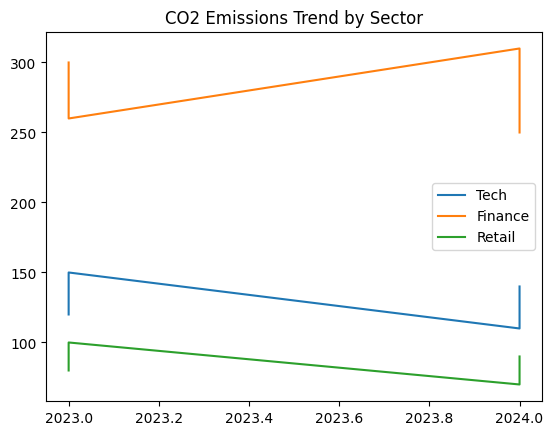

In [5]:
import matplotlib.pyplot as plt

for sector in data["sector"].unique():
    subset = data[data["sector"] == sector]
    plt.plot(subset["year"], subset["co2_emissions"], label=sector)

plt.title("CO2 Emissions Trend by Sector")
plt.legend()
plt.show()

In [12]:
# DESCRPITIVE STATS

data[["co2_emissions", "energy_usage", "employees"]].describe()

,co2_emissions,energy_usage,employees
count,12.000000,12.000000,12.000000
mean,165.000000,536.666667,99.333333
std,89.188259,242.649517,62.201043
min,70.000000,280.000000,40.000000
25%,97.500000,347.500000,53.750000
50%,130.000000,440.000000,72.500000
75%,252.500000,785.000000,151.250000
max,310.000000,920.000000,210.000000


In [7]:
# Mean vs Median
data["co2_emissions"].mean()
data["co2_emissions"].median()

np.float64(130.0)

In [ ]:
#SD 
data["co2_emissions"].std()
# hIGH sd = more variability in emissions across companies, while a low sd indicates more consistency.

np.float64(89.18825850158447)

In [ ]:
# Correlation between emissions, energy usage, and employees
data[["co2_emissions", "energy_usage", "employees"]].corr()

# +1 = perfect positive correlation, -1 = perfect negative correlation, 0 = no correlation


,co2_emissions,energy_usage,employees
co2_emissions,1.000000,0.999343,0.985028
energy_usage,0.999343,1.000000,0.984820
employees,0.985028,0.984820,1.000000


In [ ]:

display(data[["co2_emissions", "energy_usage", "employees"]].describe())

,co2_emissions,energy_usage,employees
count,12.000000,12.000000,12.000000
mean,165.000000,536.666667,99.333333
std,89.188259,242.649517,62.201043
min,70.000000,280.000000,40.000000
25%,97.500000,347.500000,53.750000
50%,130.000000,440.000000,72.500000
75%,252.500000,785.000000,151.250000
max,310.000000,920.000000,210.000000


In [ ]:
# Outliers- seeing if there are any companies with unusually high or low emissions compared to the rest of the dataset. We can use the IQR method to identify outliers.
q1 = data["co2_emissions"].quantile(0.25)
q3 = data["co2_emissions"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

lower, upper

(np.float64(-135.0), np.float64(485.0))